In [1]:
import argparse
import os
import os.path as op
import numpy as np
import nibabel as nib
import nilearn
from nilearn.connectome import ConnectivityMeasure
from nilearn import signal
import pandas as pd

In [2]:
bids_folder = "/mnt_01/ds-ASD"

# target folder for CM
import os.path as op

target_folder = op.join(bids_folder, "derivatives", "correlation_matrices")

import os
os.makedirs(target_folder,exist_ok=True)

# Jetzt kann man main() nutzen
main("00053", bids_folder, target_folder, task="fmri", ses="00001", space="fsaverage5")


In [3]:
runs_per_sub_thresh = 2

In [5]:
# Parameter definieren, fMRI Daten laden
def cleanTS(sub, fmriprep_confounds_include, bids_folder,
            TR=2.3, ses="1", task="magjudge", 
            runs=range(1,7), space="fsaverage5",
            scrubbing=True, scrub_thresh=0.3,
            run_FD_filter=True, frames_per_run_thresh=104,
            bp_filtering=True, lower_bpf=0.01, upper_bpf=0.08):
    
    fmriprep_folder = op.join(bids_folder, "derivatives", "fmriprep", f"sub-{sub}", f"ses-{ses}", "func")

    # Anzahl Vertices je nach Space
    if space == "fsaverage5":
        number_of_vertices = 20484
    elif space == "fsaverage":
        number_of_vertices = 327684

    clean_ts_runs = np.empty([number_of_vertices,0])
    N_valid_runs = 0

    for run in runs:
        try:
            # 1. Load fMRI data (surface)
            timeseries = [None] * 2
            for i, hemi in enumerate(["L", "R"]):
                filename = op.join(
                    fmriprep_folder,
                    f"sub-{sub}_ses-{ses}_task-{task}_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii"
                )
                print("Loading:", filename)
                timeseries[i] = nib.load(filename).agg_data()
            timeseries = np.vstack(timeseries)  # shape: vertices × timepoints
            
            # 2. Load confounds
            confound_file = op.join(
                fmriprep_folder,
                f"sub-{sub}_ses-{ses}_task-{task}_run-{run}_desc-confounds_timeseries.tsv"
            )
            fmriprep_confounds = pd.read_table(confound_file)[fmriprep_confounds_include]
            fmriprep_confounds = fmriprep_confounds.bfill()
            
            # 3. Scrubbing
            if scrubbing:
                fd = pd.read_table(confound_file)["framewise_displacement"]
                sample_mask = (fd < scrub_thresh).to_numpy()
                usable_frames = np.sum(sample_mask)
                if run_FD_filter and usable_frames < frames_per_run_thresh:
                    print(f"Run {run} has only {usable_frames} usable frames, skipping.")
                    continue
            else:
                sample_mask = None

            # 4. Cleaning
            clean_ts = signal.clean(
                timeseries.T,
                confounds=fmriprep_confounds,
                sample_mask=sample_mask,
                t_r=TR,
                standardize="zscore_sample",
                low_pass=upper_bpf if bp_filtering else None,
                high_pass=lower_bpf if bp_filtering else None
            ).T

            # 5. Concatenate runs
            clean_ts_runs = np.append(clean_ts_runs, clean_ts, axis=1)
            N_valid_runs += 1

        except Exception as e:
            print(f"Error in sub-{sub}, run-{run}: {e}")

    return clean_ts_runs, N_valid_runs


In [6]:
def main(sub, bids_folder_in, bids_folder_out,
         confspec="32P", ses=1, task="magjudge", space="fsaverage5",
         scrubbing=True, scrub_thresh=0.3,
         run_FD_filter=True, frames_per_run_thresh=104,
         bp_filtering=True, lower_bpf=0.01, upper_bpf=0.08):

    sub = f"{int(sub):02d}"   # Sub-ID zweistellig

    # === Confounds specification ===
    mov_params = ['trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']
    if confspec == "36P":
        general_params = ['csf','white_matter','global_signal']
    elif confspec == "32P":
        general_params = ['csf','white_matter']
    base_params = mov_params + general_params

    fmriprep_confounds_include = base_params.copy()
    for param in base_params:
        fmriprep_confounds_include.append(param + "_derivative1")
        fmriprep_confounds_include.append(param + "_power2")
        fmriprep_confounds_include.append(param + "_derivative1_power2")

    # === Run cleaning ===
    clean_ts, N_valid_runs = cleanTS(
        sub, fmriprep_confounds_include, bids_folder_in,
        task=task, ses=ses, space=space,
        scrubbing=scrubbing, scrub_thresh=scrub_thresh,
        run_FD_filter=run_FD_filter, frames_per_run_thresh=frames_per_run_thresh,
        bp_filtering=bp_filtering, lower_bpf=lower_bpf, upper_bpf=upper_bpf
    )

    if N_valid_runs < runs_per_sub_thresh:
        print(f"Sub-{sub} excluded: only {N_valid_runs} runs usable.")
        return

    # === Correlation matrix ===
    correlation_measure = ConnectivityMeasure(kind="correlation")
    cm = correlation_measure.fit_transform([clean_ts.T])[0]

    # === Save ===
    fn = op.join(
        bids_folder_out, "derivatives", "correlation_matrices",
        f"sub-{sub}_ses-{ses}_task-{task}_space-{space}_confspec-{confspec}_CM.npy"
    )
    os.makedirs(op.dirname(fn), exist_ok=True)
    np.save(fn, cm)
    print(f"Saved correlation matrix for sub-{sub} → {fn}")

In [7]:
main("01", "/mnt_01/ds-dnumrisk", "/mnt_01/ds-dnumrisk")


Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-1_space-fsaverage5_hemi-L_bold.func.gii
Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-1_space-fsaverage5_hemi-R_bold.func.gii


/tmp/ipykernel_69275/3290170911.py:53: FutureWarning: By default the cubic spline interpolator extrapolates the out-of-bounds censored volumes in the data run. This can lead to undesired filtered signal results. Starting in version 0.13, the default strategy will be not to extrapolate but to discard those volumes at filtering.
  clean_ts = signal.clean(
/tmp/ipykernel_69275/3290170911.py:53: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_ts = signal.clean(


Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-2_space-fsaverage5_hemi-L_bold.func.gii
Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-2_space-fsaverage5_hemi-R_bold.func.gii


/tmp/ipykernel_69275/3290170911.py:53: FutureWarning: By default the cubic spline interpolator extrapolates the out-of-bounds censored volumes in the data run. This can lead to undesired filtered signal results. Starting in version 0.13, the default strategy will be not to extrapolate but to discard those volumes at filtering.
  clean_ts = signal.clean(
/tmp/ipykernel_69275/3290170911.py:53: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  clean_ts = signal.clean(


Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-3_space-fsaverage5_hemi-L_bold.func.gii
Error in sub-01, run-3: No such file or no access: '/mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-3_space-fsaverage5_hemi-L_bold.func.gii'
Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-4_space-fsaverage5_hemi-L_bold.func.gii
Error in sub-01, run-4: No such file or no access: '/mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-4_space-fsaverage5_hemi-L_bold.func.gii'
Loading: /mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-5_space-fsaverage5_hemi-L_bold.func.gii
Error in sub-01, run-5: No such file or no access: '/mnt_01/ds-dnumrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-magjudge_run-5_space-fsaverage5_hemi-L_bold.func.gii'
Loading: /mnt_01/ds-dnumrisk/deriv

In [8]:
import numpy as np

cm = np.load("/mnt_01/ds-dnumrisk/derivatives/correlation_matrices/sub-01_ses-1_task-magjudge_space-fsaverage5_confspec-32P_CM.npy")

print(cm.shape)    # Grösse der Matrix
print(cm[0:5, 0:5])  # kleine Vorschau

(20484, 20484)
[[ 1.          0.13944584  0.43050844 -0.04723254  0.27974533]
 [ 0.13944584  1.         -0.21923667 -0.0385939  -0.03806974]
 [ 0.43050844 -0.21923667  1.         -0.1018138   0.26769799]
 [-0.04723254 -0.0385939  -0.1018138   1.         -0.06245826]
 [ 0.27974533 -0.03806974  0.26769799 -0.06245826  1.        ]]


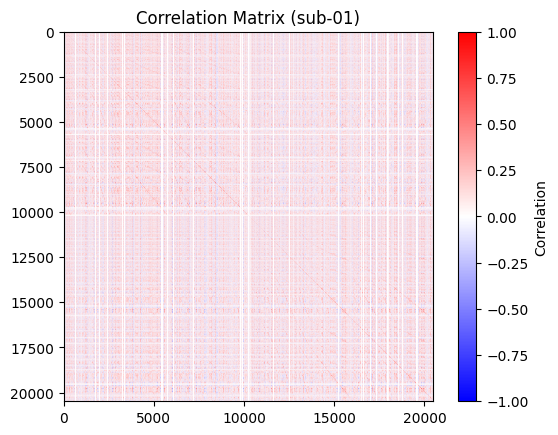

In [9]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.imshow(cm, vmin=-1, vmax=1, cmap="bwr")
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix (sub-01)")
plt.show()
